<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns',None)

In [6]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.shape

(200, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


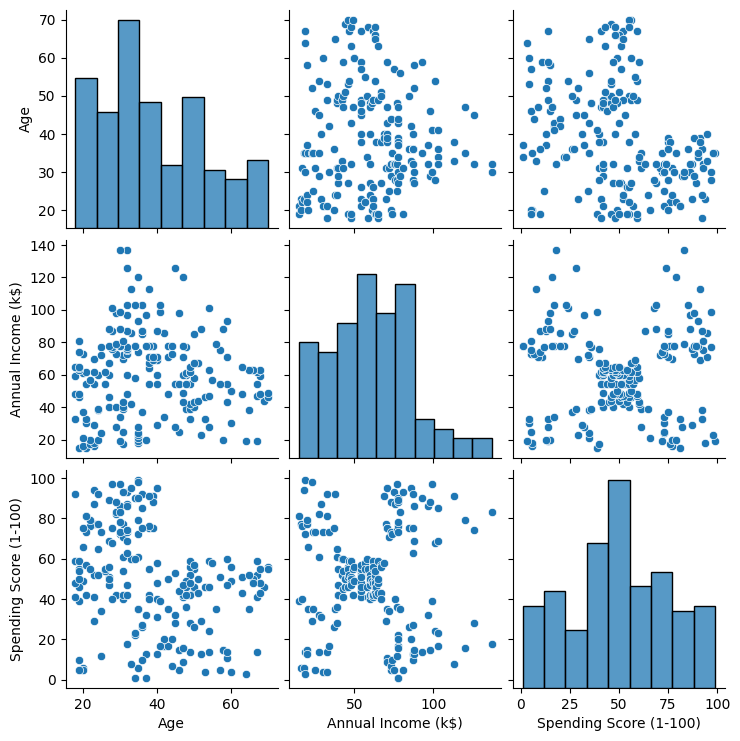

In [11]:
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.show()

In [12]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

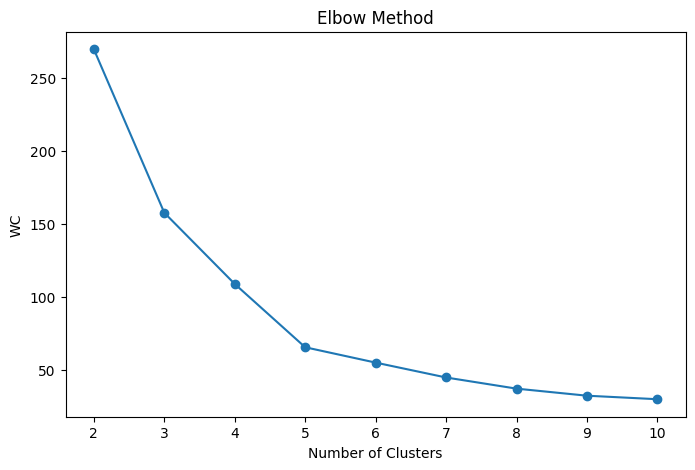

In [14]:
wc = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wc.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),wc,marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WC')
plt.title('Elbow Method')

plt.show()


# k=3

In [15]:
kmeans3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans3.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [16]:
df['Cluster'].value_counts()

,count
Cluster,
2,123
1,39
0,38


In [17]:

centers = scaler.inverse_transform(kmeans3.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

centers_df

,Annual Income,Spending Score
0,87.000000,18.631579
1,86.538462,82.128205
2,44.154472,49.829268


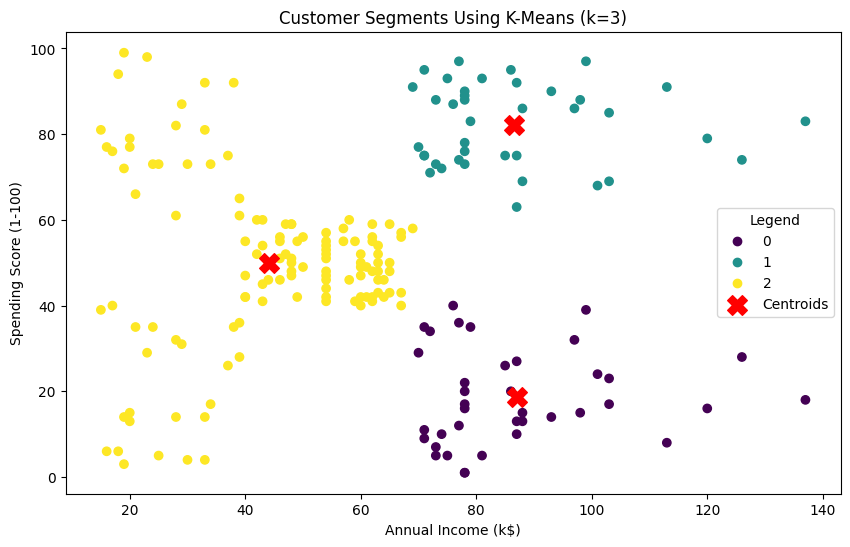

In [18]:

plt.figure(figsize=(10,6))

sc = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

centers_correct = scaler.inverse_transform(kmeans3.cluster_centers_)
centroids = plt.scatter(
    centers_correct[:,0],
    centers_correct[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

handles, labels = sc.legend_elements(prop="colors")
handles.append(centroids)
labels.append('Centroids')

plt.legend(handles, labels, title="Legend")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using K-Means (k=3)')
plt.show()

# k=4

In [19]:

kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans4.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


In [20]:
df['Cluster'].value_counts()

,count
Cluster,
2,100
3,39
1,38
0,23


In [21]:
centers = scaler.inverse_transform(kmeans4.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

centers_df

,Annual Income,Spending Score
0,26.304348,20.913043
1,87.000000,18.631579
2,48.260000,56.480000
3,86.538462,82.128205


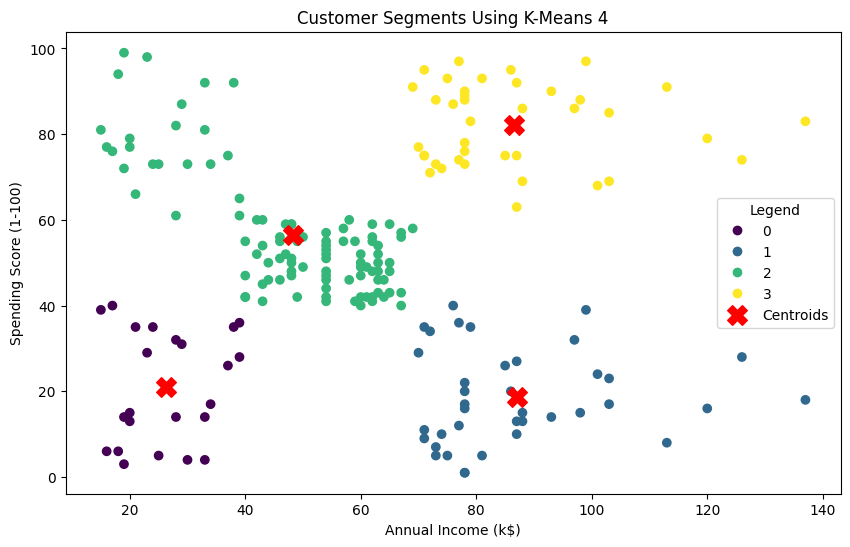

In [22]:
plt.figure(figsize=(10,6))

sc = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

# make sure this matches the KMeans object you actually fit with n_clusters=4
centers_correct = scaler.inverse_transform(kmeans4.cluster_centers_)
centroids = plt.scatter(
    centers_correct[:,0],
    centers_correct[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

# combine cluster legend + centroid legend
handles, labels = sc.legend_elements(prop="colors")
handles.append(centroids)
labels.append('Centroids')

plt.legend(handles, labels, title="Legend")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using K-Means 4')
plt.show()

# k=5

In [25]:
kmeans5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans5.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [26]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [27]:
centers = scaler.inverse_transform(kmeans5.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

centers_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


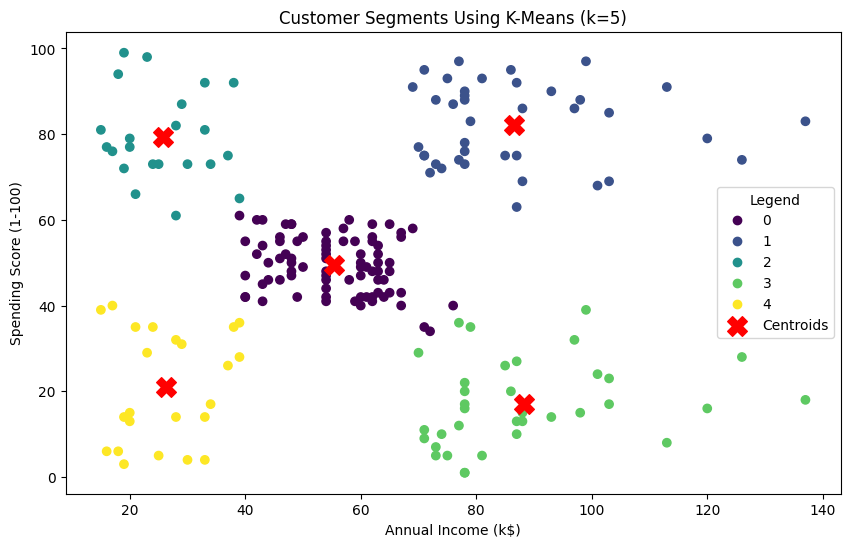

In [28]:
plt.figure(figsize=(10,6))

sc = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

centers_correct = scaler.inverse_transform(kmeans5.cluster_centers_)
centroids = plt.scatter(
    centers_correct[:,0],
    centers_correct[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

# combine cluster legend + centroid legend
handles, labels = sc.legend_elements(prop="colors")
handles.append(centroids)
labels.append('Centroids')

plt.legend(handles, labels, title="Legend")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using K-Means (k=5)')
plt.show()

# k=6

In [29]:

kmeans6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans6.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


In [30]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,35
5,29
3,23
4,22
2,10


In [31]:
centers = scaler.inverse_transform(kmeans6.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

centers_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,88.200000,17.114286
2,109.700000,82.000000
3,26.304348,20.913043
4,25.727273,79.363636
5,78.551724,82.172414


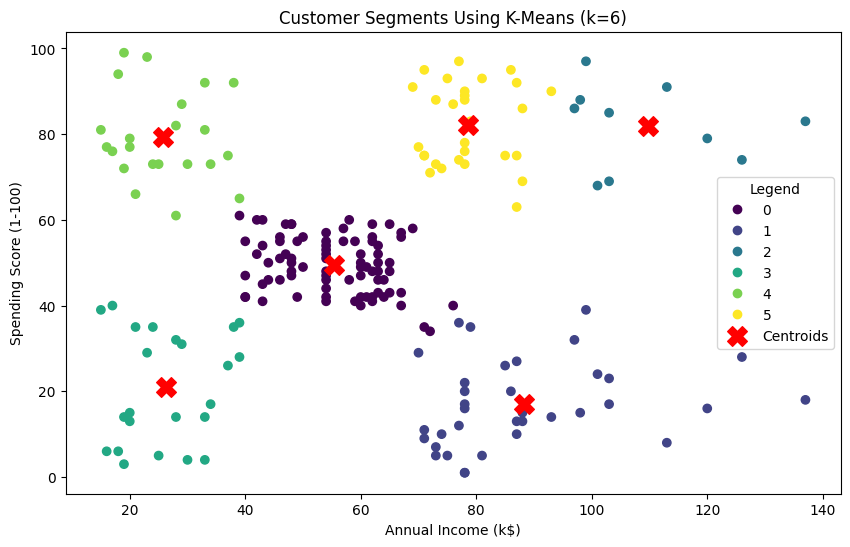

In [32]:
# fit KMeans with k=6
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters6 = kmeans6.fit_predict(X_scaled)
df['Cluster'] = clusters6

# plot
plt.figure(figsize=(10,6))

sc = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

centers_correct = scaler.inverse_transform(kmeans6.cluster_centers_)
centroids = plt.scatter(
    centers_correct[:,0],
    centers_correct[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

handles, labels = sc.legend_elements(prop="colors")
handles.append(centroids)
labels.append('Centroids')

plt.legend(handles, labels, title="Legend")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using K-Means (k=6)')
plt.show()